In [2]:
import scvi


/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/scvi/_settings.py:63: UserWarning: Since v1.0.0, scvi-tools no longer uses a random seed by default. Run `scvi.settings.seed = 0` to reproduce results from previous versions.
  self.seed = seed
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/scvi/_settings.py:70: UserWarning: Setting `dl_pin_memory_gpu_training` is deprecated in v1.0 and will be removed in v1.1. Please pass in `pin_memory` to the data loaders instead.
  self.dl_pin_memory_gpu_training = (


## Heuristic 1: inversely proportional to number of cells

In [3]:
from functools import reduce
import numpy as np
import matplotlib.pyplot as plt

def plot_scvi_epochs_heuristic(decay_at_n_obs=20000, epochs_cap=200):
    n_obs = np.concatenate([np.array([1, 2, 5]) * 10**n for n in range(2, 7)])
    epochs = [scvi.model._utils.get_max_epochs_heuristic(n,decay_at_n_obs=decay_at_n_obs, epochs_cap=epochs_cap) for n in n_obs]
    plt.plot(n_obs, epochs, label=str(decay_at_n_obs))


/var/folders/w9/llll0v7j02zdytwd43sshysm0000gp/T/ipykernel_25894/4201507329.py:7: UserWarning: The default number of maximum epochs has been set to 1 due to the largenumber of observations. Pass in `max_epochs` to the `train` function in order to override this behavior.
  epochs = [scvi.model._utils.get_max_epochs_heuristic(n,decay_at_n_obs=decay_at_n_obs, epochs_cap=epochs_cap) for n in n_obs]


Text(0, 0.5, 'epochs')

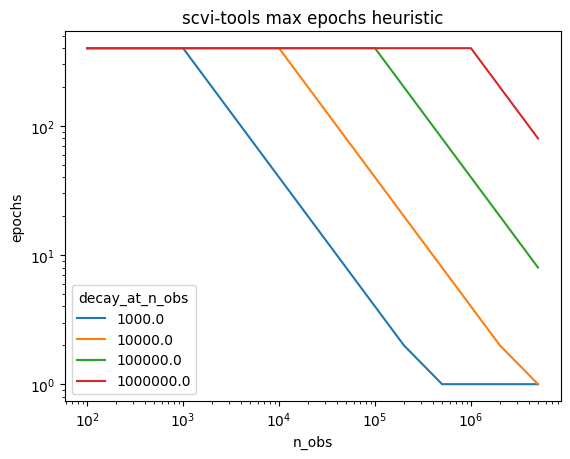

In [44]:
for decay_at_n_obs in [1e3,1e4,1e5,1e6]:
    plot_scvi_epochs_heuristic(decay_at_n_obs=decay_at_n_obs)
plt.legend(title="decay_at_n_obs")
plt.loglog()
plt.title("scvi-tools max epochs heuristic")
plt.xlabel("n_obs")
plt.ylabel("epochs")

In [88]:
# scvi.model._utils.get_max_epochs_heuristic(100)
# scvi.model._utils.get_max_epochs_heuristic(1000)
# batch_size = 512
# batch_size=128
scvi.model._utils.get_max_epochs_heuristic(1000000, epochs_cap=1000, decay_at_n_obs=5000)
scvi.model._utils.get_max_epochs_heuristic(1000000, epochs_cap=1000, decay_at_n_obs=5000)

# scvi.model._utils.get_max_epochs_heuristic(50000)


5

## Heuristic 2: constant number of minibatches

Text(0, 0.5, 'epochs')

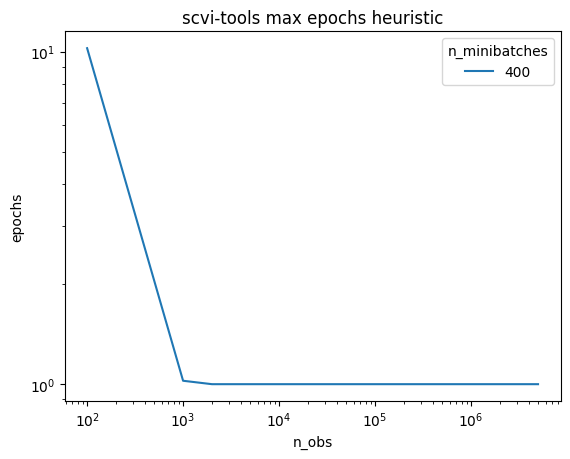

In [50]:
n_minibatches = 400
minibatch_size = 1024

from functools import reduce
import numpy as np
import matplotlib.pyplot as plt

def plot_minibatch_epochs_heuristic(n_minibatches=400, minibatch_size=1024, max_epochs=400):
    n_obs = np.concatenate([np.array([1, 2, 5]) * 10**n for n in range(2, 7)])
    epochs = np.clip(minibatch_size/n_obs, a_min=1, a_max=max_epochs)
    plt.plot(n_obs, epochs, label=str(n_minibatches))

plot_minibatch_epochs_heuristic()
plt.legend(title="n_minibatches")
plt.loglog()
plt.title("scvi-tools max epochs heuristic")
plt.xlabel("n_obs")
plt.ylabel("epochs")